In [10]:
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import pickle
import time

%matplotlib inline
import sys

import jax
from jax import config

config.update("jax_enable_x64", True)


import equinox as eqx

os.getcwd()
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../"))
sys.path.append(os.path.abspath("../../"))

In [11]:
from yancc.field import Field
from yancc.solve import solve_dke, solve_dke_ambipolar
from yancc.species import Electron, Hydrogen, LocalMaxwellian
from yancc.velocity_grids import MaxwellSpeedGrid, UniformPitchAngleGrid

In [12]:
booz_path = "./Benchmark-MONKES-JAX/W7X-KJM/boozmn_KJM.nc"
pkl_path = "benchmark_w7x_kjm_ambipolar.pkl"

rho = 0.1919  # r = 0.1 m

# Low resolution, for testing the workflow.
# nt = 13
# nz = 27
# na = 49
# nx = 6

# resolution for ~1% accuracy
nt = 31
nz = 97
na = 181
nx = 6

# scan range, for plotting only
Erho_scan = np.linspace(-1000.0, 4000.0, 30)  # V
rtol = 1e-6  # Krylov tolerance for the scan
num_roots = 3  # ion root, electron root and the unstable root in between

In [13]:
field = Field.from_booz_xform(booz_path, rho, nt, nz)
pitchgrid = UniformPitchAngleGrid(na)
speedgrid = MaxwellSpeedGrid(nx)

In [14]:
Ti = 1150
Te = 2650
ni = 6e19
ne = 6e19
dTe = -4600
dTi = -1000
dni = 0.0
dne = 0.0

ions = LocalMaxwellian(Hydrogen, Ti, ni, dTi, dni)
electrons = LocalMaxwellian(Electron, Te, ne, dTe, dne)

species = [
    ions,
    electrons,
]
for name, sp in zip(["ion", "electron"], species):
    print(f"{name}: T = {sp.temperature:.1f} eV, n = {sp.density:.3e} m^-3")

# Erho = -dPhi/drho [V] is the radial electric field in flux-surface label units. E* =
# Erho / Escale is the field normalized to the ion thermal speed at x = 1, which sets the
# default search bounds of the ambipolar solver.
Escale = field.a_minor * species[0].v_thermal * field.Bmag_fsa
print(f"Erho per unit E*: {float(Escale):.4e} V")

ion: T = 1150.0 eV, n = 6.000e+19 m^-3
electron: T = 2650.0 eV, n = 6.000e+19 m^-3
Erho per unit E*: 5.6895e+05 V


## Erho scan

In [6]:
config_data = dict(
    booz_path=booz_path,
    rho=rho,
    nt=nt,
    nz=nz,
    na=na,
    nx=nx,
    rtol=rtol,
    Ti=float(species[0].temperature),
    Te=float(species[1].temperature),
    n=float(species[0].density),
)
scan_keys = ["Erho", "particle_flux", "heat_flux", "J_rho", "nmv", "success", "time"]

data = None
if os.path.exists(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)
    if data["config"] != config_data:
        print("existing pickle has a different configuration, starting over")
        data = None
if data is None:
    data = {"config": config_data, "scan": {k: [] for k in scan_keys}}

done = list(data["scan"]["Erho"])
for Erho in Erho_scan:
    if any(np.isclose(Erho, d) for d in done):
        continue
    t0 = time.perf_counter()
    sol, info = solve_dke(
        field,
        pitchgrid,
        speedgrid,
        species,
        Erho,
        rtol=rtol,
        verbose=2,
        m=100,
    )
    sol = jax.block_until_ready(sol)
    dt = time.perf_counter() - t0
    row = dict(
        Erho=float(Erho),
        particle_flux=np.asarray(sol.get("<particle_flux>")),
        heat_flux=np.asarray(sol.get("<heat_flux>")),
        J_rho=float(sol.get("J_rho")),
        nmv=int(info["nmv"]),
        success=bool(info["success"]),
        time=dt,
    )
    for k in scan_keys:
        data["scan"][k].append(row[k])
    with open(pkl_path, "wb") as f:
        pickle.dump(data, f)
    print(
        f"Erho = {Erho:+7.1f} V  Gamma_i = {row['particle_flux'][0]:.4e}  "
        f"Gamma_e = {row['particle_flux'][1]:.4e}  J_rho = {row['J_rho']:+.3e}  "
        f"nmv = {row['nmv']}  converged = {row['success']}  time = {dt:.0f} s",
        flush=True,
    )

In [7]:
from matplotlib import rcParams

matplotlib.rcdefaults()
rcParams["font.family"] = "DejaVu Serif"
rcParams["mathtext.fontset"] = "cm"
rcParams["font.size"] = 10
rcParams["figure.facecolor"] = (1, 1, 1, 1)
rcParams["figure.figsize"] = (6, 4)
rcParams["lines.markersize"] = 4
rcParams["xtick.labelsize"] = 10
rcParams["ytick.labelsize"] = 10

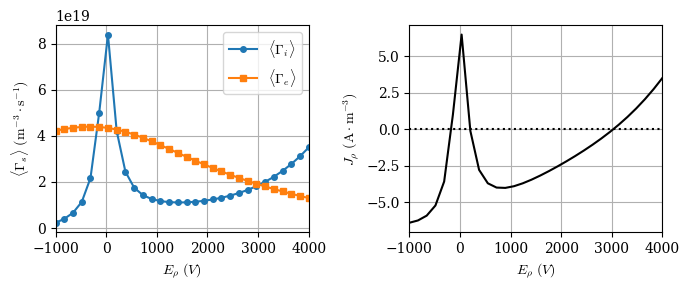

In [20]:
from scipy.interpolate import PchipInterpolator


def plot_scan(data, savename=None, roots=False, deflation_length=None):
    """Plot the fluxes and radial current from the scan.

    If ``roots`` is True, the ambipolar roots are marked. If ``deflation_length`` is
    also given, the radial current after successively deflating each root (in the
    order they were found) is drawn as dashed lines, with ``deflation_length`` the
    width of the search bounds.
    """
    scan = {k: np.array(v) for k, v in data["scan"].items()}
    order = np.argsort(scan["Erho"])
    Erho = scan["Erho"][order]
    Gamma = scan["particle_flux"][order]
    Jrho = scan["J_rho"][order]

    deflated = roots and deflation_length is not None
    fig, ax = plt.subplots(1, 2, figsize=(7, 3.6 if deflated else 3), sharex=True)
    ax[0].plot(Erho, Gamma[:, 0], "o-", label=r"$\langle\Gamma_i\rangle$")
    ax[0].plot(Erho, Gamma[:, 1], "s-", label=r"$\langle\Gamma_e\rangle$")
    ax[0].set_ylabel(r"$\langle \Gamma_s \rangle ~ \mathrm{(m^{-3} \cdot s^{-1})}$")
    ax[0].legend()
    ax[1].plot(Erho, Jrho, "k-", label=r"$J_\rho$")
    ax[1].axhline(0, c="k", ls=":")
    ax[1].set_ylabel(r"$J_\rho ~ \mathrm{(A \cdot m^{-3})}$")

    if roots:
        roots = data["roots"]
        ok = np.asarray(roots["success"], dtype=bool)
        Erho_root = np.asarray(roots["Erho"])[ok]
        for x in Erho_root:
            ax[1].axvline(x, c="k", ls="--", lw=0.8)
        ax[1].scatter(
            Erho_root,
            np.asarray(roots["J_rho"])[ok],
            c="r",
            marker="x",
            zorder=3,
            label="ambipolar roots",
        )
        if deflated:
            # The solver deflates J_rho by prod_i (L / (E - E_i) + 1) for each root
            # E_i already found, where L is the width of the search bounds. The
            # scan is too coarse to resolve the cancellation of the pole at each root,
            # so the scan is interpolated with J_rho set to exactly zero at the roots.
            Eint = np.concatenate([Erho, Erho_root])
            Jint = np.concatenate([Jrho, np.zeros_like(Erho_root)])
            srt = np.argsort(Eint)
            J_interp = PchipInterpolator(Eint[srt], Jint[srt])
            Efine = np.linspace(Erho.min(), Erho.max(), 2001)
            Jfine = J_interp(Efine)
            factor = np.ones_like(Efine)
            for i, x in enumerate(Erho_root[:-1]):
                with np.errstate(divide="ignore", invalid="ignore"):
                    factor = factor * (deflation_length / (Efine - x) + 1)
                ax[1].plot(
                    Efine,
                    factor * Jfine,
                    "--",
                    c=f"C{i}",
                    label=f"deflated {i + 1} root" + ("s" if i else ""),
                )
            # deflated currents are orders of magnitude larger than J_rho itself, so
            # J_rho is kept in the linear region and only they extend into the log
            # region
            linthresh = 10 ** np.ceil(np.log10(np.abs(Jrho).max()))
            ax[1].set_yscale("symlog", linthresh=linthresh)
            ax[1].legend(
                loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, fontsize=7
            )
        else:
            ax[1].legend()
    for a in ax:
        a.set_xlim(Erho.min(), Erho.max())
        a.grid(True)
        a.set_xlabel(r"$E_\rho ~(V)$")
    ax[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    if not deflated:
        ax[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    fig.set_tight_layout(True)
    if savename is not None:
        fig.savefig(savename + ".pdf")
        fig.savefig(savename + ".png")
    return fig, ax


fig, ax = plot_scan(data, "benchmark_w7x_kjm_ambipolar")

## Ambipolar roots

Cold start, independent of the scan above (which is only for plotting): no initial guess and
no bounds are given, so the search uses the default bounds $E^* \in (-0.1, 0.1)$ and starts from their
middle, falling back to sign changes and sampling of the bounds to find the other roots.

In [9]:
t0 = time.perf_counter()
Erho_roots, root_sols, root_info = eqx.filter_jit(solve_dke_ambipolar)(
    field, pitchgrid, speedgrid, species, num_roots, verbose=2, m=100
)
Erho_roots = jax.block_until_ready(Erho_roots)
root_time = time.perf_counter() - t0
print("TIME:", root_time)

W0923 15:56:37.186219  965528 hlo_rematerialization.cc:3231] Can't reduce memory use below 37.16GiB (39897224533 bytes) by rematerialization; only reduced to 43.61GiB (46824425254 bytes), down from 43.61GiB (46824460231 bytes) originally


E0923 15:58:19.214624  965616 slow_operation_alarm.cc:73] 
********************************
[Compiling module jit_solve_dke_ambipolar for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


E0923 15:58:53.743199  965528 slow_operation_alarm.cc:140] The operation took 2m34.528674061s

********************************
[Compiling module jit_solve_dke_ambipolar for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


E0923 15:58:56.420093  965528 cuda_executor.cc:1182] [0] Failed to allocate device memory of 28.97GiB (31107055616 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


Field info (source: booz_xform):
    ρ         =  0.192              ι         = -8.710e-01
    <B>       =  2.469e+00 T        δ_B       =  7.189e-02
    Bmax/Bmin =  1.264e+00          f_trapped =  4.884e-01
    I         = -4.218e-18 T·m      G         =  1.440e+01 T·m
Species  0:  m= 1.00e+00 (mₚ)      q= 1.00e+00 (qₚ)
             n= 6.00e+19 (m⁻³)  a/Lₙ=-0.00e+00
             T= 1.15e+03 (eV)   a/Lᴛ= 8.70e-01  
             ν* (x=7.86e-02):  5.091e+01
             ν* (x=1.00e+00):  2.075e-02
             ν* (x=3.04e+00):  3.733e-04
Species  1:  m= 5.45e-04 (mₚ)      q=-1.00e+00 (qₚ)
             n= 6.00e+19 (m⁻³)  a/Lₙ=-0.00e+00
             T= 2.65e+03 (eV)   a/Lᴛ= 1.74e+00  
             ν* (x=7.86e-02):  1.574e+02
             ν* (x=1.00e+00):  9.389e-03
             ν* (x=3.04e+00):  1.318e-04
Grid 0: nx=   6, nα=  16, nθ=   5, nζ=   8, N=7,680
Grid 1: nx=   6, nα=  41, nθ=   7, nζ=  22, N=75,768
Grid 2: nx=   6, nα=  86, nθ=  15, nζ=  46, N=712,080
Grid 3: nx=   6, nα= 181, 

...

Finished krylov: nmv= 120, n_restarts=  1, residual=1.054e-05
<heat_flux>    : [ 1.022e+04  4.615e+04 ] (per species, kg·m⁻¹·s⁻³ = W·m⁻³)
<particle_flux>: [ 1.898e+19  1.869e+19 ] (per species, m⁻³·s⁻¹)
<V||B>         : [ 3.211e+03  7.734e+02 ] (per species, T·m·s⁻¹)
<J||B>         :  2.344e+04 (A·T·m⁻³)
J_rho          :  4.610e-02 (A·m⁻³)
Newton step   2,  x= 3.027971e+03,  xc= 3.027971e+03,  df= 2.109040e-01,  f= 3.296261e+00,  oob=  0,  0


Finished krylov: nmv=  94, n_restarts=  1, residual=2.176e-06
<heat_flux>    : [ 1.016e+04  4.641e+04 ] (per species, kg·m⁻¹·s⁻³ = W·m⁻³)
<particle_flux>: [ 1.881e+19  1.880e+19 ] (per species, m⁻³·s⁻¹)
<V||B>         : [ 3.196e+03  7.666e+02 ] (per species, T·m·s⁻¹)
<J||B>         :  2.335e+04 (A·T·m⁻³)
J_rho          :  1.938e-03 (A·m⁻³)
Newton step   3,  x= 3.027277e+03,  xc= 3.027277e+03,  df= 2.019478e-01,  f= 1.399940e-01,  oob=  0,  0


Finished krylov: nmv=  52, n_restarts=  1, residual=9.892e-07
<heat_flux>    : [ 1.016e+04  4.642e+04 ] (per species, kg·m⁻¹·s⁻³ = W·m⁻³)
<particle_flux>: [ 1.880e+19  1.880e+19 ] (per species, m⁻³·s⁻¹)
<V||B>         : [ 3.195e+03  7.654e+02 ] (per species, T·m·s⁻¹)
<J||B>         :  2.335e+04 (A·T·m⁻³)
J_rho          :  8.031e-06 (A·m⁻³)
Newton step   4,  x= 3.027274e+03,  xc= 3.027274e+03,  df= 2.011117e-01,  f= 5.802622e-04,  oob=  0,  0
Search   7, phase 0, x= 3.0273e+03, f= 3.8327e-07, steps=  5


Finished krylov: nmv=  31, n_restarts=  0, residual=9.892e-07


<heat_flux>    : [ 1.016e+04  4.642e+04 ] (per species, kg·m⁻¹·s⁻³ = W·m⁻³)
<particle_flux>: [ 1.880e+19  1.880e+19 ] (per species, m⁻³·s⁻¹)
<V||B>         : [ 3.195e+03  7.654e+02 ] (per species, T·m·s⁻¹)
<J||B>         :  2.335e+04 (A·T·m⁻³)
J_rho          :  8.031e-06 (A·m⁻³)
Newton step   0,  x= 3.027274e+03,  xc= 3.027274e+03,  df= 1.345291e-04,  f= 3.832694e-07,  oob=  0,  0
Search   7, phase 1, x= 3.0273e+03, f= 3.8327e-07, steps=  6
Search   7: start= 3.5141e+03, bounds=( 1.5163e+03, 1.7174e+04), success=True, x= 3.0273e+03, f= 3.8327e-07, steps=  6
Root  0: success=True,  Eᵨ=-1.628673e+02 (V),  residual= 1.242e-05,  newton steps= 11,  nmv=  780
<heat_flux>    : [ 4.391e+04  1.128e+05 ] (per species, kg·m⁻¹·s⁻³ = W·m⁻³)
<particle_flux>: [ 4.396e+19  4.396e+19 ] (per species, m⁻³·s⁻¹)
<V||B>         : [ 4.017e+02  6.462e+03 ] (per species, T·m·s⁻¹)
<J||B>         : -5.826e+04 (A·T·m⁻³)
J_rho          :  2.602e-04 (A·m⁻³)
Root  1: success=True,  Eᵨ= 2.028274e+02 (V),  residual= 3

In [10]:
success = np.asarray(root_info["success"], dtype=bool)
Erho_roots = np.asarray(Erho_roots)  # V, inf if not found
print(
    "Erho [V]  converged  |J_rho|/sum|q Gamma| (residual)  matvecs since previous root"
)
for i in range(num_roots):
    print(
        f"{Erho_roots[i]:+9.2f}  {bool(success[i])!s:>9}  "
        f"{float(root_info['residual'][i]):.2e}  {int(root_info['nmv'][i])}"
    )
print("total matvecs:", int(root_info["nmv_total"]))

data["roots"] = dict(
    Erho=Erho_roots,
    success=success,
    residual=np.asarray(root_info["residual"]),
    newton_steps=np.asarray(root_info["newton_steps"]),
    nmv=np.asarray(root_info["nmv"]),
    nmv_total=int(root_info["nmv_total"]),
    time=root_time,
    particle_flux=np.array([np.asarray(s.get("<particle_flux>")) for s in root_sols]),
    heat_flux=np.array([np.asarray(s.get("<heat_flux>")) for s in root_sols]),
    J_rho=np.array([float(s.get("J_rho")) for s in root_sols]),
)
with open(pkl_path, "wb") as f:
    pickle.dump(data, f)

Erho [V]  converged  |J_rho|/sum|q Gamma| (residual)  matvecs since previous root


  -162.87       True  1.24e-05  780
  +202.83       True  3.06e-11  3334
 +3027.28       True  3.83e-07  861
total matvecs: 5194


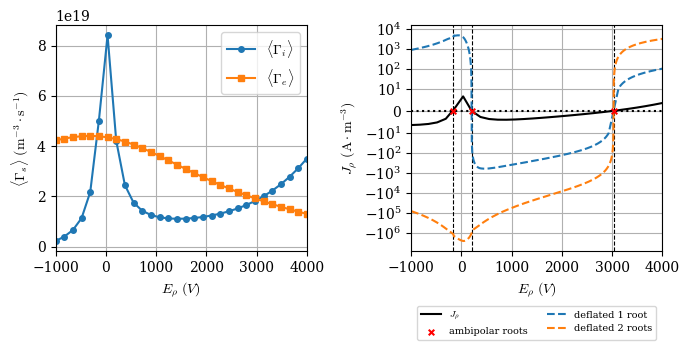

In [21]:
with open(pkl_path, "rb") as f:
    data = pickle.load(f)
# default search bounds are E* in (-0.1, 0.1)
fig, ax = plot_scan(
    data,
    "benchmark_w7x_kjm_ambipolar_roots",
    True,
    deflation_length=2 * 0.1 * float(Escale),
)